In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment is ready.")

Environment is ready.


In [3]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/beijing_pm25.csv")

df = pd.read_csv(DATA_PATH)

print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

First 5 rows:
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0

Shape:
(43824, 13)

Columns:
['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']

Missing values:
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64


In [4]:
# Create datetime column
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# Sort by time
df = df.sort_values("datetime").reset_index(drop=True)

print("Datetime range:")
print(df["datetime"].min())
print(df["datetime"].max())

# Rename columns for easier modeling
df = df.rename(columns={
    "pm2.5": "pollution",
    "DEWP": "dew",
    "TEMP": "temp",
    "PRES": "press",
    "Iws": "wnd_spd",
    "Is": "snow",
    "Ir": "rain"
})

print("\nColumns after renaming:")
print(df.columns.tolist())

print("\nMissing values after renaming:")
print(df.isna().sum())

Datetime range:
2010-01-01 00:00:00
2014-12-31 23:00:00

Columns after renaming:
['No', 'year', 'month', 'day', 'hour', 'pollution', 'dew', 'temp', 'press', 'cbwd', 'wnd_spd', 'snow', 'rain', 'datetime']

Missing values after renaming:
No              0
year            0
month           0
day             0
hour            0
pollution    2067
dew             0
temp            0
press           0
cbwd            0
wnd_spd         0
snow            0
rain            0
datetime        0
dtype: int64


In [5]:
# Reproduction version:
# Fill missing PM2.5 values with 0 to reproduce the original Minitab workflow.
# This is not the statistically best method, but it is used here for traceability.

df_repro = df.copy()
df_repro["pollution"] = df_repro["pollution"].fillna(0)

# Create lagged PM2.5 features
for lag in [1, 2, 3]:
    df_repro[f"pollution_Lag{lag}"] = df_repro["pollution"].shift(lag)

print("First 10 rows with lagged features:")
print(df_repro[[
    "datetime",
    "pollution",
    "pollution_Lag1",
    "pollution_Lag2",
    "pollution_Lag3"
]].head(10))

print("\nMissing values in lagged features:")
print(df_repro[[
    "pollution",
    "pollution_Lag1",
    "pollution_Lag2",
    "pollution_Lag3"
]].isna().sum())

First 10 rows with lagged features:
             datetime  pollution  pollution_Lag1  pollution_Lag2  \
0 2010-01-01 00:00:00        0.0             NaN             NaN   
1 2010-01-01 01:00:00        0.0             0.0             NaN   
2 2010-01-01 02:00:00        0.0             0.0             0.0   
3 2010-01-01 03:00:00        0.0             0.0             0.0   
4 2010-01-01 04:00:00        0.0             0.0             0.0   
5 2010-01-01 05:00:00        0.0             0.0             0.0   
6 2010-01-01 06:00:00        0.0             0.0             0.0   
7 2010-01-01 07:00:00        0.0             0.0             0.0   
8 2010-01-01 08:00:00        0.0             0.0             0.0   
9 2010-01-01 09:00:00        0.0             0.0             0.0   

   pollution_Lag3  
0             NaN  
1             NaN  
2             NaN  
3             0.0  
4             0.0  
5             0.0  
6             0.0  
7             0.0  
8             0.0  
9             0

In [6]:
# Split train and test sets by time
# Do not use random split for this time-series-style regression project.

train = df_repro[
    (df_repro["datetime"] >= "2010-01-01 00:00:00") &
    (df_repro["datetime"] <= "2014-12-24 23:00:00")
].copy()

test = df_repro[
    (df_repro["datetime"] >= "2014-12-25 00:00:00") &
    (df_repro["datetime"] <= "2014-12-31 23:00:00")
].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain datetime range:")
print(train["datetime"].min())
print(train["datetime"].max())

print("\nTest datetime range:")
print(test["datetime"].min())
print(test["datetime"].max())

Train shape: (43656, 17)
Test shape: (168, 17)

Train datetime range:
2010-01-01 00:00:00
2014-12-24 23:00:00

Test datetime range:
2014-12-25 00:00:00
2014-12-31 23:00:00


In [7]:
# Define features and target variable

features = [
    "dew", "temp", "press", "wnd_spd", "snow", "rain",
    "pollution_Lag1", "pollution_Lag2", "pollution_Lag3"
]

target = "pollution"

# Drop rows with missing values in model variables
# The first 3 training rows have missing lag values.

train_model = train.dropna(subset=features + [target]).copy()
test_model = test.dropna(subset=features + [target]).copy()

print("Train model shape:", train_model.shape)
print("Test model shape:", test_model.shape)

print("\nMissing values in train_model:")
print(train_model[features + [target]].isna().sum())

print("\nMissing values in test_model:")
print(test_model[features + [target]].isna().sum())

Train model shape: (43653, 17)
Test model shape: (168, 17)

Missing values in train_model:
dew               0
temp              0
press             0
wnd_spd           0
snow              0
rain              0
pollution_Lag1    0
pollution_Lag2    0
pollution_Lag3    0
pollution         0
dtype: int64

Missing values in test_model:
dew               0
temp              0
press             0
wnd_spd           0
snow              0
rain              0
pollution_Lag1    0
pollution_Lag2    0
pollution_Lag3    0
pollution         0
dtype: int64


In [8]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import numpy as np

# Prepare training data
X_train = train_model[features]
y_train = train_model[target]

# Add intercept term for OLS regression
X_train_const = sm.add_constant(X_train)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_const).fit()

# Print regression summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              pollution   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                 5.129e+04
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        18:27:12   Log-Likelihood:            -2.0595e+05
No. Observations:               43653   AIC:                         4.119e+05
Df Residuals:                   43643   BIC:                         4.120e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             98.3658     24.294      4.

In [9]:
# Extract key training metrics

train_r2 = ols_model.rsquared
train_adj_r2 = ols_model.rsquared_adj
train_resid = ols_model.resid

# Minitab's S is approximately the residual standard error
train_s = np.sqrt(np.sum(train_resid ** 2) / ols_model.df_resid)

dw_stat = durbin_watson(train_resid)

print("Training metrics:")
print(f"R-squared: {train_r2:.6f}")
print(f"Adjusted R-squared: {train_adj_r2:.6f}")
print(f"S / Residual standard error: {train_s:.6f}")
print(f"Durbin-Watson: {dw_stat:.6f}")

print("\nRegression coefficients:")
print(ols_model.params)

Training metrics:
R-squared: 0.913620
Adjusted R-squared: 0.913602
S / Residual standard error: 27.084649
Durbin-Watson: 1.995136

Regression coefficients:
const             98.365774
dew                0.310956
temp              -0.424900
press             -0.085797
wnd_spd           -0.016379
snow              -0.091234
rain              -0.884674
pollution_Lag1     0.959758
pollution_Lag2     0.003146
pollution_Lag3    -0.025375
dtype: float64


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare test data
X_test = test_model[features]
y_test = test_model[target]

X_test_const = sm.add_constant(X_test)

# Predict PM2.5 on the test set
y_pred = ols_model.predict(X_test_const)

# Save predictions and errors
test_model = test_model.copy()
test_model["prediction"] = y_pred
test_model["error"] = y_test - y_pred

print("First 10 prediction results:")
print(test_model[[
    "datetime",
    "pollution",
    "prediction",
    "error"
]].head(10))

First 10 prediction results:
                 datetime  pollution  prediction      error
43656 2014-12-25 00:00:00       20.0   20.219627  -0.219627
43657 2014-12-25 01:00:00       22.0   22.475970  -0.475970
43658 2014-12-25 02:00:00       22.0   24.210021  -2.210021
43659 2014-12-25 03:00:00       10.0   26.110276 -16.110276
43660 2014-12-25 04:00:00       14.0   14.180211  -0.180211
43661 2014-12-25 05:00:00       14.0   19.629818  -5.629818
43662 2014-12-25 06:00:00       18.0   20.930988  -2.930988
43663 2014-12-25 07:00:00       13.0   23.789403 -10.789403
43664 2014-12-25 08:00:00       18.0   18.951932  -0.951932
43665 2014-12-25 09:00:00       27.0   21.896194   5.103806


In [11]:
# Calculate test-set error metrics

errors = y_test - y_pred

mad = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Avoid division by zero when calculating percentage errors
nonzero_mask = y_test != 0

mape = np.mean(
    np.abs((y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask])
) * 100

mpe = np.mean(
    (y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask]
) * 100

metrics = {
    "MAD": mad,
    "MSE": mse,
    "RMSE": rmse,
    "MAPE": mape,
    "MPE": mpe
}

print("Test-set metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

Test-set metrics:
MAD: 18.813214
MSE: 870.109807
RMSE: 29.497624
MAPE: 26.637482
MPE: -10.525987


In [12]:
from pathlib import Path

# Create output folders if they do not exist
Path("../outputs").mkdir(parents=True, exist_ok=True)

# Save regression summary
with open("../outputs/regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(ols_model.summary().as_text())

# Save reproduction metrics
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("../outputs/reproduction_metrics.csv", index=False)

print("Saved regression summary to ../outputs/regression_summary.txt")
print("Saved metrics to ../outputs/reproduction_metrics.csv")
print(metrics_df)

Saved regression summary to ../outputs/regression_summary.txt
Saved metrics to ../outputs/reproduction_metrics.csv
         MAD         MSE       RMSE       MAPE        MPE
0  18.813214  870.109807  29.497624  26.637482 -10.525987


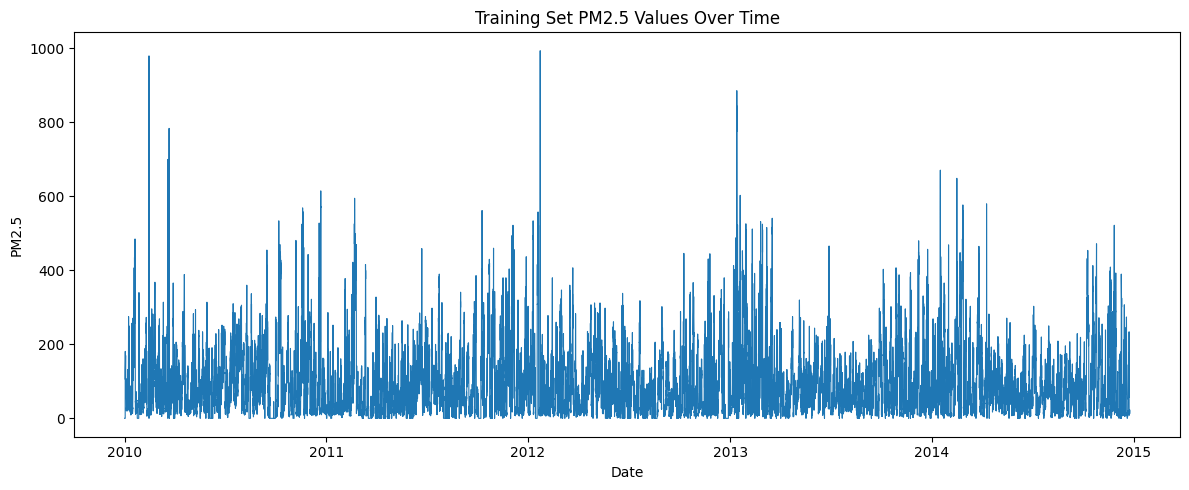

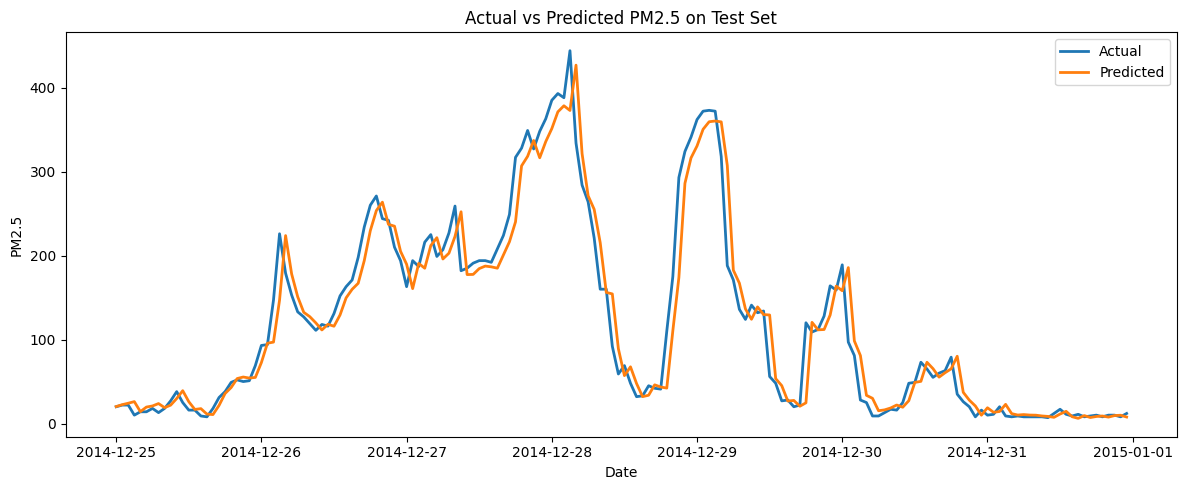

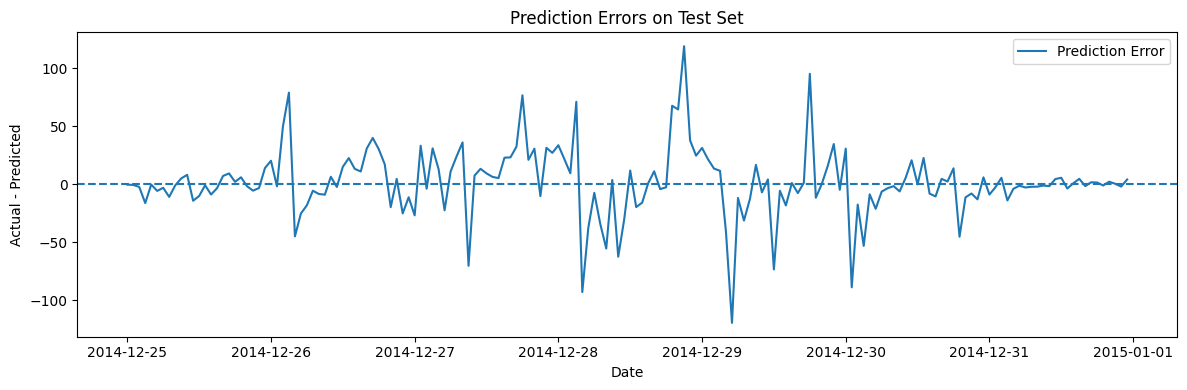

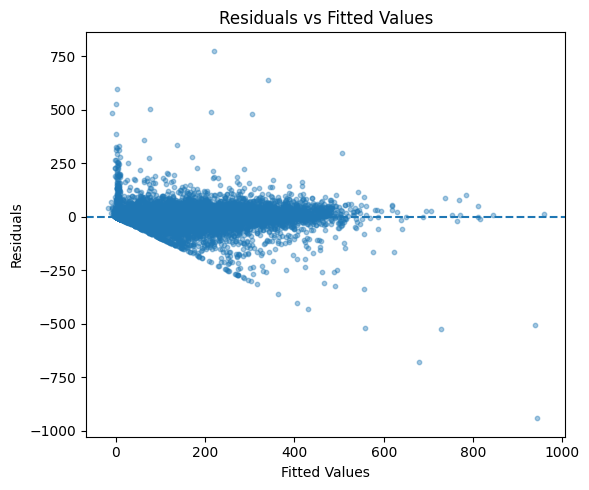

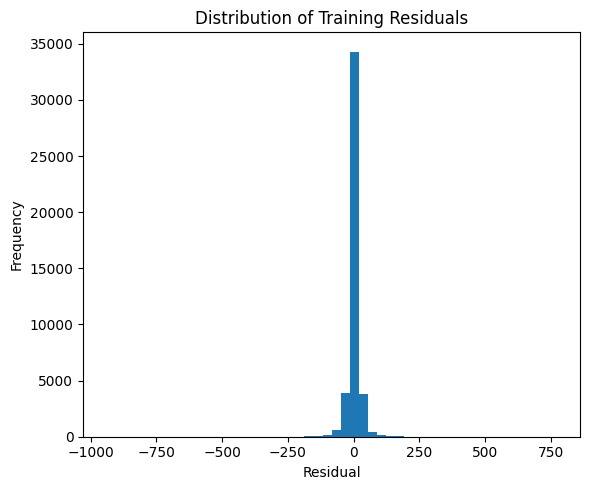

All figures saved to ../figures/


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
Path("../figures").mkdir(parents=True, exist_ok=True)

# 1. Training set PM2.5 time series
plt.figure(figsize=(12, 5))
plt.plot(train["datetime"], train["pollution"], linewidth=0.8)
plt.title("Training Set PM2.5 Values Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.savefig("../figures/training_pollution_timeseries.png", dpi=300)
plt.show()

# 2. Actual vs Predicted on test set
plt.figure(figsize=(12, 5))
plt.plot(test_model["datetime"], y_test.values, label="Actual", linewidth=2)
plt.plot(test_model["datetime"], y_pred.values, label="Predicted", linewidth=2)
plt.title("Actual vs Predicted PM2.5 on Test Set")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/actual_vs_predicted.png", dpi=300)
plt.show()

# 3. Prediction errors on test set
plt.figure(figsize=(12, 4))
plt.plot(test_model["datetime"], errors.values, label="Prediction Error", linewidth=1.5)
plt.axhline(0, linestyle="--")
plt.title("Prediction Errors on Test Set")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/prediction_errors.png", dpi=300)
plt.show()

# 4. Residuals vs fitted values
fitted = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(6, 5))
plt.scatter(fitted, residuals, alpha=0.4, s=10)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("../figures/residuals_vs_fitted.png", dpi=300)
plt.show()

# 5. Residual distribution
plt.figure(figsize=(6, 5))
plt.hist(residuals, bins=50)
plt.title("Distribution of Training Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../figures/residual_distribution.png", dpi=300)
plt.show()

print("All figures saved to ../figures/")